In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:

# 1. Set up the exact file paths
csv_path = r'C:\Users\HP\Downloads\2) Stock Prices Data Set.csv'
xlsx_path = r'C:\Users\HP\Downloads\2) Stock Prices Data Set.xlsx'

In [28]:
# 2. Automatically select and load whichever file exists
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Successfully loaded CSV file!")
else:
    df = pd.read_excel(xlsx_path)
    print("Successfully loaded Excel file!")

Successfully loaded CSV file!


In [29]:
# 3. Standardize column headers to lowercase
df.columns = df.columns.str.strip().str.lower()

# 4. Handle Date sorting dynamically
date_cols = [col for col in df.columns if 'date' in col or 'time' in col]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]])
    df = df.sort_values(date_cols[0]).reset_index(drop=True)
    print(f"Sorted chronologically by: '{date_cols[0]}'")

Sorted chronologically by: 'date'


In [30]:
# 5. Extract numeric columns and calculate returns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
close_cols = [col for col in num_cols if 'close' in col]
if close_cols:
    df['daily_return'] = df[close_cols[0]].pct_change()
    num_cols.append('daily_return')


In [31]:
# =====================================================================
# OBJECTIVE 1: Summary Statistics
# =====================================================================
print("\n" + "="*50)
print("OBJECTIVE 1: SUMMARY STATISTICS")
print("="*50)
print(df[num_cols].describe())
print("\n--- MODE VALUES ---")
print(df[num_cols].mode().iloc[0:1])



OBJECTIVE 1: SUMMARY STATISTICS
                open           high            low          close  \
count  497461.000000  497464.000000  497464.000000  497472.000000   
mean       86.352275      87.132562      85.552467      86.369082   
std       101.471228     102.312062     100.570957     101.472407   
min         1.620000       1.690000       1.500000       1.590000   
25%        41.690000      42.090000      41.280000      41.703750   
50%        64.970000      65.560000      64.353700      64.980000   
75%        98.410000      99.230000      97.580000      98.420000   
max      2044.000000    2067.990000    2035.110000    2049.000000   

             volume   daily_return  
count  4.974720e+05  497471.000000  
mean   4.253611e+06       0.709239  
std    8.232139e+06       3.023183  
min    0.000000e+00      -0.992992  
25%    1.080166e+06      -0.485854  
50%    2.084896e+06       0.009908  
75%    4.271928e+06       0.880602  
max    6.182376e+08     121.283951  

--- MODE VA


Generating visual plots...


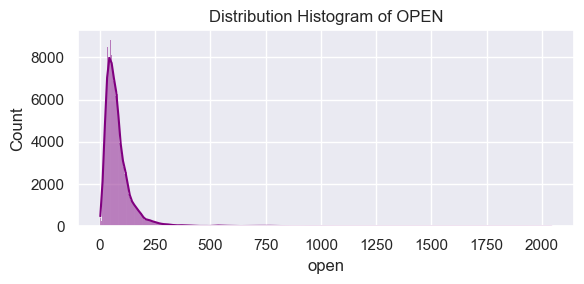

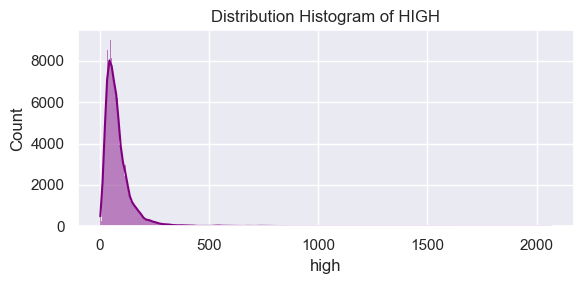

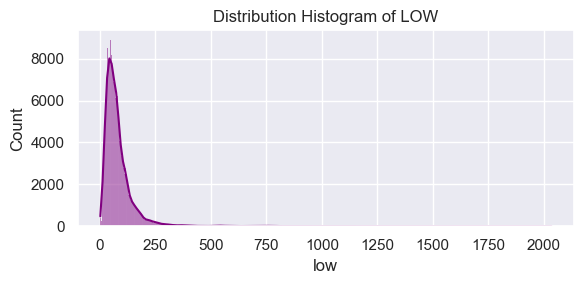

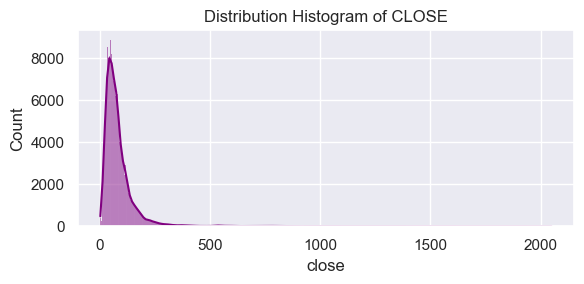

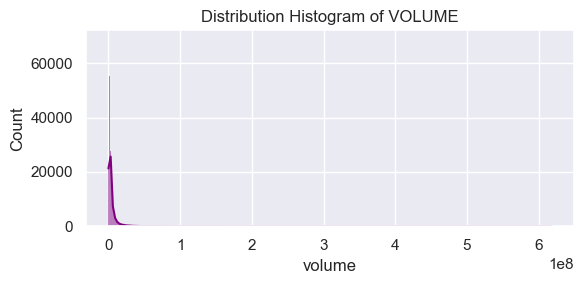

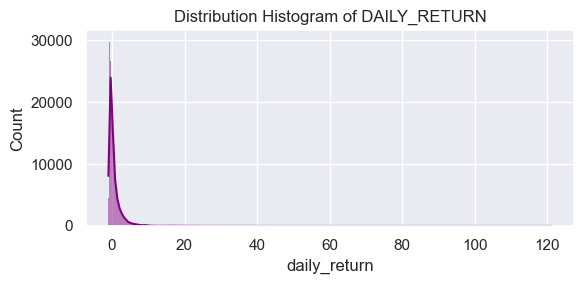

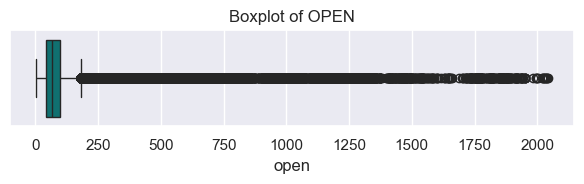

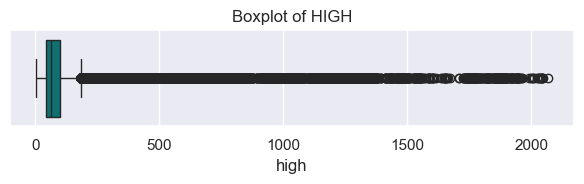

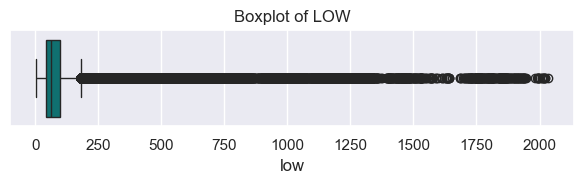

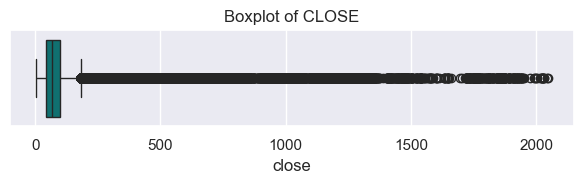

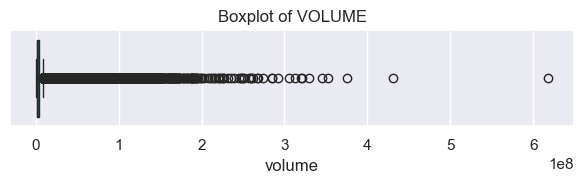

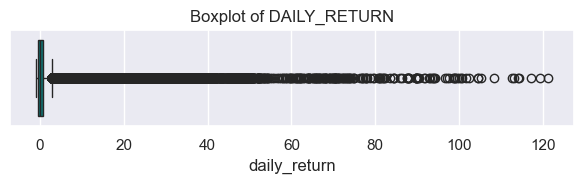

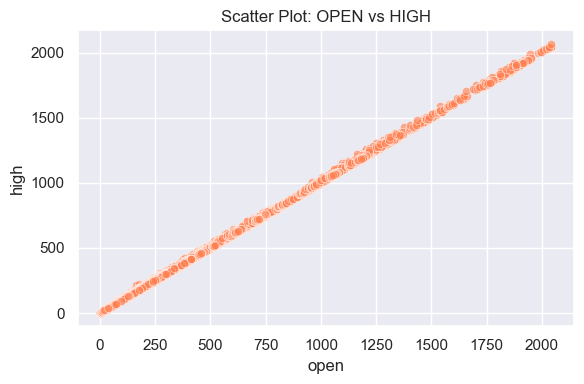

In [34]:
# =====================================================================
# OBJECTIVE 2: Visualizations (Histograms & Boxplots)
# =====================================================================
print("\nGenerating visual plots...")
sns.set_theme(style="darkgrid")
# Histograms
for col in num_cols:
    if df[col].dropna().empty: 
        continue
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True, color='purple')
    plt.title(f'Distribution Histogram of {col.upper()}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    # Boxplots
for col in num_cols:
    if df[col].dropna().empty: 
        continue
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col].dropna(), color='teal')
    plt.title(f'Boxplot of {col.upper()}')
    plt.tight_layout()
    plt.show()
    # Scatter Plot
if len(num_cols) >= 2:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=num_cols[0], y=num_cols[1], alpha=0.6, color='coral')
    plt.title(f'Scatter Plot: {num_cols[0].upper()} vs {num_cols[1].upper()}')
    plt.tight_layout()
    plt.show()



OBJECTIVE 3: CORRELATION HEATMAP


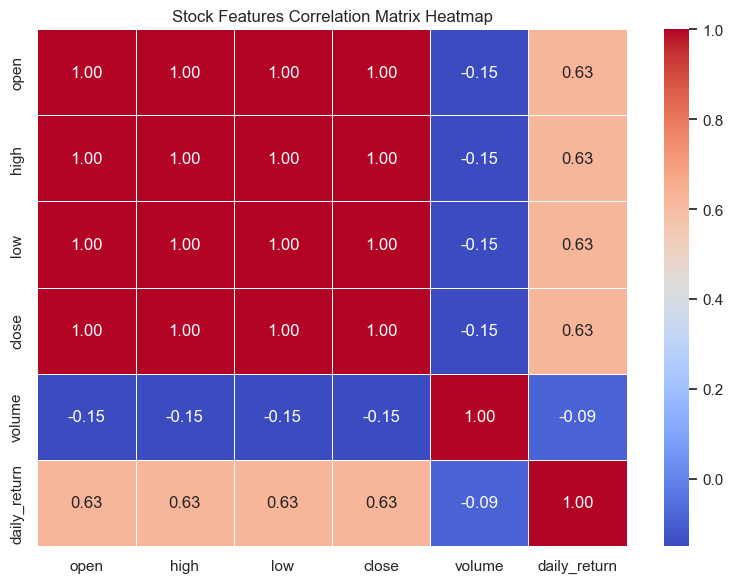

In [35]:
# =====================================================================
# OBJECTIVE 3: Correlation Matrix
# =====================================================================
print("\n" + "="*50)
print("OBJECTIVE 3: CORRELATION HEATMAP")
print("="*50)
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Stock Features Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

## Task 2: Exploratory Data Analysis (EDA) Summary

### 1. Key Findings & Trends
* *Price Attributes:* The Open, High, Low, and Close prices show a perfect positive correlation (*1.00*). This indicates that daily prices move tightly together.
* *Volume Analysis:* Trading volume has a weak negative correlation (*-0.15*) with price, meaning trading activity remains relatively steady regardless of price increases.
* *Daily Returns:* Daily returns have a moderate positive correlation (*0.63*) with overall stock prices.

### 2. Summary Statistics
* *Average Closing Price (Mean):* 86.37
* *Volatility (Std Dev):* 101.47